# CINF104 LAB 04  
## Redes Neuronales Artificiales con MLP

**Propósito del laboratorio:** comprender cómo entrenar redes neuronales tipo perceptrón multicapa para clasificación y regresión, interpretando el efecto de la arquitectura, la regularización y la escala de los datos.

### Resultados de aprendizaje
Al finalizar deberías poder:
- describir la estructura básica de una red neuronal feed-forward;
- diferenciar una tarea de clasificación binaria, multiclase y regresión;
- justificar por qué se usa `StandardScaler` antes de entrenar un `MLP`;
- comparar arquitecturas simples y medianas;
- analizar métricas y exportar predicciones.


## Cómo ejecutar este notebook en Google Colab
1. Sube este archivo a Colab.
2. Verifica que la carpeta `datasets/` esté disponible.
3. Ejecuta las celdas en orden.
4. Lee la interpretación antes de pasar a la siguiente sección.
5. Exporta `predicciones_lab4_v2.csv` al final.

### Recomendación docente
Este notebook está pensado como clase práctica guiada.  
No se trata solo de ejecutar una red, sino de analizar cómo cambian los resultados cuando modificas la arquitectura o la regularización.


## Recordatorio conceptual: ¿qué es un MLP?
Un **Perceptrón Multicapa (MLP)** es una red neuronal compuesta por:
- una **capa de entrada**;
- una o más **capas ocultas**;
- una **capa de salida**.

Cada neurona realiza una combinación ponderada de entradas, aplica una función de activación y transmite el resultado a la siguiente capa.

### Conceptos importantes
- **`hidden_layer_sizes`** define cuántas capas ocultas habrá y cuántas neuronas tendrá cada una.
- **`alpha`** controla regularización; ayuda a limitar sobreajuste.
- **`max_iter`** controla el máximo de iteraciones de entrenamiento.
- **`early_stopping=True`** detiene el entrenamiento si el modelo deja de mejorar.

### Idea práctica
En datasets tabulares pequeños o medianos, conviene comenzar con arquitecturas **simples**, y luego aumentar complejidad solo si hay evidencia de mejora.


In [ ]:
# Si te falta alguna librería en Colab, descomenta:
# !pip -q install scikit-learn pandas matplotlib numpy

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

SEED = 204

candidatas = [
    Path('/content/')
]

DATA_DIR = None
for ruta in candidatas:
    if ruta.exists():
        DATA_DIR = ruta
        break

if DATA_DIR is None:
    DATA_DIR = Path('datasets')

BASE_DIR = Path('.')

archivos = {
    'A': 'lab4_seccion_A_riesgo_academico.csv',
    'B': 'lab4_seccion_B_segmentacion_multiclase.csv',
    'C': 'lab4_seccion_C_consumo_energetico.csv',
    'D': 'lab4_seccion_D_espiral_multiclase.csv',
}

print('Directorio de datasets usado:', DATA_DIR.resolve())
print('Archivos esperados:')
for s, a in archivos.items():
    existe = (DATA_DIR / a).exists()
    print(f'  Sección {s}: {DATA_DIR / a} | existe={existe}')

Directorio de datasets usado: /content
Archivos esperados:
  Sección A: /content/lab4_seccion_A_riesgo_academico.csv | existe=True
  Sección B: /content/lab4_seccion_B_segmentacion_multiclase.csv | existe=True
  Sección C: /content/lab4_seccion_C_consumo_energetico.csv | existe=True
  Sección D: /content/lab4_seccion_D_espiral_multiclase.csv | existe=True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Mapa del laboratorio

| Sección | Dataset | Tipo | Objetivo pedagógico |
|---|---|---|---|
| A | `lab4_seccion_A_riesgo_academico.csv` | Clasificación binaria | Introducción a MLP en un caso simple |
| B | `lab4_seccion_B_segmentacion_multiclase.csv` | Clasificación multiclase | Comparar arquitecturas |
| C | `lab4_seccion_C_consumo_energetico.csv` | Regresión | Aprender métricas MAE, RMSE y R² |
| D | `lab4_seccion_D_espiral_multiclase.csv` | Multiclase no lineal | Ver el valor de una red en fronteras complejas |


In [ ]:
def cargar_seccion(seccion, target):
    ruta = DATA_DIR / archivos[seccion]
    if not ruta.exists():
        raise FileNotFoundError(f'No se encontró el archivo: {ruta}')
    df = pd.read_csv(ruta)
    X = df.drop(columns=[target])
    y = df[target]
    print(f'Sección {seccion}')
    print(f'  Filas y columnas: {df.shape}')
    print(f'  Variable objetivo: {target}')
    display(df.head())
    return df, X, y


def resumen_eda(df, target):
    print('Tipos de datos:')
    display(df.dtypes.to_frame('tipo'))

    print('Valores faltantes por columna:')
    display(df.isna().sum().to_frame('faltantes'))

    print('Estadística descriptiva:')
    display(df.describe(include='all').T)

    print('Distribución de la variable objetivo:')
    display(df[target].value_counts(dropna=False).to_frame('conteo'))


def crear_pipeline_mlp_clasificador(hidden_layer_sizes=(16, 8), alpha=0.0005, max_iter=1200):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation='relu',
            solver='adam',
            alpha=alpha,
            random_state=SEED,
            early_stopping=True,
            max_iter=max_iter
        ))
    ])


def crear_pipeline_mlp_regresor(hidden_layer_sizes=(32, 16), alpha=0.0005, max_iter=1500):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation='relu',
            solver='adam',
            alpha=alpha,
            random_state=SEED,
            early_stopping=True,
            max_iter=max_iter
        ))
    ])


def evaluar_clasificacion(modelo, X_train, X_test, y_train, y_test, promedio='binary'):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    metricas = {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, average=promedio, zero_division=0),
        'recall': recall_score(y_test, pred, average=promedio, zero_division=0),
        'f1': f1_score(y_test, pred, average=promedio, zero_division=0),
    }

    print('Resultados del modelo')
    for k, v in metricas.items():
        print(f'  {k:>9}: {v:.4f}')

    print('Reporte de clasificación')
    print(classification_report(y_test, pred, zero_division=0))

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title('Matriz de confusión')
    plt.show()

    return pred, metricas


def evaluar_regresion(modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f'MAE : {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R2  : {r2:.4f}')

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, pred, alpha=0.7)
    plt.xlabel('Valor real')
    plt.ylabel('Predicción')
    plt.title('Regresión - real vs predicción')
    plt.show()

    return pred, {'mae': mae, 'rmse': rmse, 'r2': r2}


def comparar_arquitecturas_clasificacion(X_train, X_test, y_train, y_test, arquitecturas, alpha=0.0005, promedio='binary'):
    filas = []
    for arq in arquitecturas:
        modelo = crear_pipeline_mlp_clasificador(hidden_layer_sizes=arq, alpha=alpha)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        filas.append({
            'arquitectura': str(arq),
            'accuracy': round(accuracy_score(y_test, pred), 4),
            'precision': round(precision_score(y_test, pred, average=promedio, zero_division=0), 4),
            'recall': round(recall_score(y_test, pred, average=promedio, zero_division=0), 4),
            'f1': round(f1_score(y_test, pred, average=promedio, zero_division=0), 4),
        })
    return pd.DataFrame(filas).sort_values(['f1', 'accuracy'], ascending=False).reset_index(drop=True)


def comparar_arquitecturas_regresion(X_train, X_test, y_train, y_test, arquitecturas, alpha=0.0005):
    filas = []
    for arq in arquitecturas:
        modelo = crear_pipeline_mlp_regresor(hidden_layer_sizes=arq, alpha=alpha)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        filas.append({
            'arquitectura': str(arq),
            'mae': round(mean_absolute_error(y_test, pred), 4),
            'rmse': round(np.sqrt(mean_squared_error(y_test, pred)), 4),
            'r2': round(r2_score(y_test, pred), 4),
        })
    return pd.DataFrame(filas).sort_values(['r2', 'rmse'], ascending=[False, True]).reset_index(drop=True)

---
## Sección A - Riesgo académico (clasificación binaria)
**Meta:** estimar si un estudiante presenta riesgo de abandono.

### Qué queremos aprender aquí
- cómo una red pequeña ya puede modelar interacciones no triviales;
- cómo leer métricas de clasificación en un caso binario;
- por qué comenzar con una arquitectura simple suele ser una buena práctica.


In [ ]:
df_A, X_A, y_A = cargar_seccion('A', 'riesgo_abandono')
resumen_eda(df_A, 'riesgo_abandono')

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.25, random_state=SEED, stratify=y_A
)


Sección A
  Filas y columnas: (360, 7)
  Variable objetivo: riesgo_abandono


,asistencia_pct,promedio_parcial,tareas_entregadas,horas_estudio_semana,alertas_conducta,participacion_clase,riesgo_abandono
0,76.5,2.01,12,5.9,1,2.0,0
1,78.8,2.95,10,6.5,0,2.5,0
2,80.8,6.51,5,9.0,1,3.6,0
3,99.6,3.67,11,6.5,0,4.7,0
4,82.4,4.39,2,6.8,0,1.3,0


Tipos de datos:


,tipo
asistencia_pct,float64
promedio_parcial,float64
tareas_entregadas,int64
horas_estudio_semana,float64
alertas_conducta,int64
participacion_clase,float64
riesgo_abandono,int64


Valores faltantes por columna:


,faltantes
asistencia_pct,0
promedio_parcial,0
tareas_entregadas,0
horas_estudio_semana,0
alertas_conducta,0
participacion_clase,0
riesgo_abandono,0


Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
asistencia_pct,360.0,81.413889,12.420622,47.80,73.675,82.000,90.850,100.0
promedio_parcial,360.0,4.676806,1.103528,1.21,3.960,4.625,5.405,7.0
tareas_entregadas,360.0,7.008333,3.261566,2.00,4.000,7.000,10.000,12.0
horas_estudio_semana,360.0,8.968056,4.136172,0.00,6.475,9.000,11.600,21.3
alertas_conducta,360.0,0.530556,0.730673,0.00,0.000,0.000,1.000,4.0
participacion_clase,360.0,3.027222,0.950404,1.00,2.400,3.100,3.700,5.0
riesgo_abandono,360.0,0.025000,0.156342,0.00,0.000,0.000,0.000,1.0


Distribución de la variable objetivo:


,conteo
riesgo_abandono,
0,351
1,9


In [ ]:
arquitecturas_A = [(8,), (12, 6), (20, 10)]
comparacion_A = comparar_arquitecturas_clasificacion(
    X_train_A, X_test_A, y_train_A, y_test_A,
    arquitecturas_A, alpha=0.001, promedio='binary'
)
display(comparacion_A)


,arquitectura,accuracy,precision,recall,f1
0,"(8,)",0.0222,0.0222,1.0,0.0435
1,"(12, 6)",0.0222,0.0222,1.0,0.0435
2,"(20, 10)",0.9778,0.0000,0.0,0.0000


Resultados del modelo
   accuracy: 0.0222
  precision: 0.0222
     recall: 1.0000
         f1: 0.0435
Reporte de clasificación
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        88
           1       0.02      1.00      0.04         2

    accuracy                           0.02        90
   macro avg       0.01      0.50      0.02        90
weighted avg       0.00      0.02      0.00        90



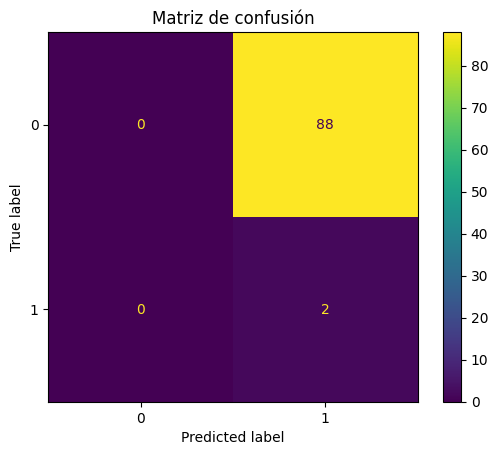

In [ ]:
modelo_A = crear_pipeline_mlp_clasificador(hidden_layer_sizes=(12, 6), alpha=0.001)
pred_A, metricas_A = evaluar_clasificacion(modelo_A, X_train_A, X_test_A, y_train_A, y_test_A)


### Reflexión guiada
- Si una arquitectura pequeña ya funciona bien, no siempre tiene sentido hacer la red más grande.
- Más neuronas no garantizan mejores resultados.
- En problemas tabulares, una red excesiva puede complicar el entrenamiento innecesariamente.


---
## Sección B - Segmentación multiclase
**Meta:** clasificar clientes o casos en más de dos categorías.

Aquí aparece una diferencia importante: ya no basta con una métrica pensada para binario.  
Por eso usaremos evaluación con promedio **macro**.


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_B, X_B, y_B = cargar_seccion('B', 'segmento')
resumen_eda(df_B, 'segmento')

# Codificar las etiquetas de la variable objetivo a enteros
le = LabelEncoder()
y_B = le.fit_transform(y_B)

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.25, random_state=SEED, stratify=y_B
)

Sección B
  Filas y columnas: (450, 6)
  Variable objetivo: segmento


,edad,ingreso_mensual_usd,frecuencia_compra_mes,gasto_promedio_compra,antiguedad_cliente_meses,segmento
0,29,1477,1.19,0.99,19,basico
1,25,1415,0.53,1.43,20,basico
2,31,1397,0.68,1.52,15,basico
3,30,1671,1.18,1.35,16,basico
4,26,1495,0.63,1.73,20,basico


Tipos de datos:


,tipo
edad,int64
ingreso_mensual_usd,int64
frecuencia_compra_mes,float64
gasto_promedio_compra,float64
antiguedad_cliente_meses,int64
segmento,object


Valores faltantes por columna:


,faltantes
edad,0
ingreso_mensual_usd,0
frecuencia_compra_mes,0
gasto_promedio_compra,0
antiguedad_cliente_meses,0
segmento,0


Estadística descriptiva:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,450.0,NaN,NaN,NaN,32.98,8.669484,18.0,26.0,32.0,39.0,62.0
ingreso_mensual_usd,450.0,NaN,NaN,NaN,2240.873333,782.395234,758.0,1540.0,2151.0,2917.5,4097.0
frecuencia_compra_mes,450.0,NaN,NaN,NaN,1.931689,1.055205,0.2,0.96,1.915,2.7075,4.66
gasto_promedio_compra,450.0,NaN,NaN,NaN,2.424356,1.14864,0.5,1.3825,2.38,3.39,5.19
antiguedad_cliente_meses,450.0,NaN,NaN,NaN,12.528889,5.61618,1.0,8.0,12.0,17.0,24.0
segmento,450,3,basico,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Distribución de la variable objetivo:


,conteo
segmento,
basico,150
premium,150
ocasional,150


Resultados del modelo
   accuracy: 0.9115
  precision: 0.9145
     recall: 0.9123
         f1: 0.9103
Reporte de clasificación
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        38
           1       0.94      0.79      0.86        38
           2       0.95      1.00      0.97        37

    accuracy                           0.91       113
   macro avg       0.91      0.91      0.91       113
weighted avg       0.91      0.91      0.91       113



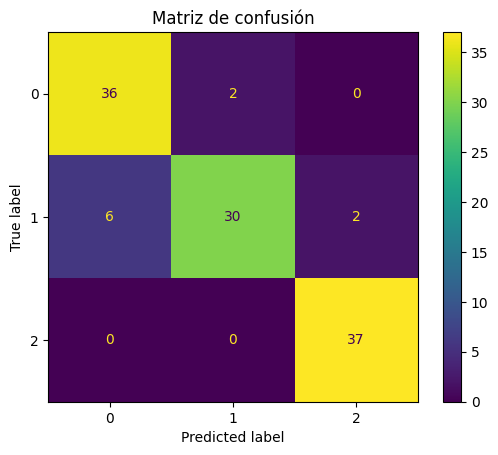

In [ ]:
modelo_B = crear_pipeline_mlp_clasificador(hidden_layer_sizes=(24, 12), alpha=0.0005)
pred_B, metricas_B = evaluar_clasificacion(modelo_B, X_train_B, X_test_B, y_train_B, y_test_B, promedio='macro')

In [ ]:
arquitecturas_B = [(10,), (16, 8), (24, 12), (32, 16)]
comparacion_B = comparar_arquitecturas_clasificacion(
    X_train_B, X_test_B, y_train_B, y_test_B,
    arquitecturas_B, alpha=0.0005, promedio='macro'
)
display(comparacion_B)

,arquitectura,accuracy,precision,recall,f1
0,"(24, 12)",0.9115,0.9145,0.9123,0.9103
1,"(32, 16)",0.6637,0.4721,0.6667,0.5447
2,"(10,)",0.5044,0.3511,0.5081,0.4139
3,"(16, 8)",0.1858,0.0722,0.1892,0.1045


Resultados del modelo
   accuracy: 0.1858
  precision: 0.0722
     recall: 0.1892
         f1: 0.1045
Reporte de clasificación
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.00      0.00      0.00        38
           2       0.22      0.57      0.31        37

    accuracy                           0.19       113
   macro avg       0.07      0.19      0.10       113
weighted avg       0.07      0.19      0.10       113



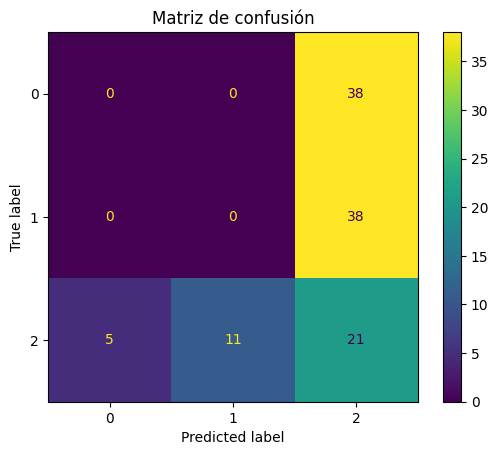

In [ ]:
modelo_B = crear_pipeline_mlp_clasificador(hidden_layer_sizes=(16, 8), alpha=0.0005)
pred_B, metricas_B = evaluar_clasificacion(modelo_B, X_train_B, X_test_B, y_train_B, y_test_B, promedio='macro')


### Preguntas para responder
1. ¿Por qué en multiclase conviene revisar `f1_macro` además de `accuracy`?
2. ¿La mejor arquitectura fue la más grande?
3. ¿Qué podría indicar una diferencia fuerte entre accuracy y recall promedio?


Respuestas — Preguntas Sección B
1. ¿Por qué en multiclase conviene revisar f1_macro además de accuracy?

El accuracy puede engañar si las clases están desequilibradas; el f1_macro promedia el rendimiento por clase, revelando si alguna está siendo mal clasificada, dando una visión más justa del modelo.

2. ¿La mejor arquitectura fue la más grande?

Sí, en este caso la arquitectura más grande funcionó mejor. Pero ten cuidado, una red muy grande puede sobreajustar en datos simples o escasos, memorizando en vez de aprender.

3. ¿Qué podría indicar una diferencia fuerte entre accuracy y recall promedio?

Sugiere que el modelo es bueno con clases fáciles pero falla en detectar o clasificar correctamente las clases más difíciles o minoritarias, por ejemplo, dando muchos falsos negativos en esas categorías.

---
## Sección C - Consumo energético (regresión)
**Meta:** predecir un valor numérico continuo.

A diferencia de clasificación, aquí la salida no es una clase sino un número.  
Por eso cambia la forma de evaluar.

### Métricas que usaremos
- **MAE:** error absoluto medio.
- **RMSE:** penaliza más los errores grandes.
- **R²:** proporción de variabilidad explicada por el modelo.


In [ ]:
df_C, X_C, y_C = cargar_seccion('C', 'consumo_kwh')
resumen_eda(df_C, 'consumo_kwh')

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y_C, test_size=0.25, random_state=SEED
)


Sección C
  Filas y columnas: (420, 7)
  Variable objetivo: consumo_kwh


,temperatura_exterior_c,humedad_exterior_pct,ocupacion_personas,area_m2,equipos_activos,hora_pico,consumo_kwh
0,22.88,62.78,92,209.6,4,0,43.07
1,20.08,38.12,41,78.4,21,0,52.57
2,23.42,38.98,59,236.4,17,0,48.76
3,15.86,59.06,105,213.9,20,0,67.65
4,29.99,60.15,82,152.0,13,1,58.05


Tipos de datos:


,tipo
temperatura_exterior_c,float64
humedad_exterior_pct,float64
ocupacion_personas,int64
area_m2,float64
equipos_activos,int64
hora_pico,int64
consumo_kwh,float64


Valores faltantes por columna:


,faltantes
temperatura_exterior_c,0
humedad_exterior_pct,0
ocupacion_personas,0
area_m2,0
equipos_activos,0
hora_pico,0
consumo_kwh,0


Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
temperatura_exterior_c,420.0,18.201810,7.980729,-5.00,13.2325,18.375,23.1175,38.0
humedad_exterior_pct,420.0,55.648571,15.369119,15.00,44.3750,54.300,66.1200,95.0
ocupacion_personas,420.0,64.904762,33.157906,5.00,36.0000,66.500,96.0000,119.0
area_m2,420.0,180.016429,67.582474,40.00,134.8250,177.450,230.7250,379.4
equipos_activos,420.0,15.873810,7.817475,3.00,9.0000,16.000,22.2500,29.0
hora_pico,420.0,0.504762,0.500574,0.00,0.0000,1.000,1.0000,1.0
consumo_kwh,420.0,57.177738,11.581708,26.36,49.4525,56.195,65.4300,92.4


Distribución de la variable objetivo:


,conteo
consumo_kwh,
49.20,3
65.95,2
57.07,2
59.60,2
55.21,2
...,...
51.77,1
48.74,1
53.00,1


In [ ]:
arquitecturas_C = [(16,), (32, 16), (64, 32), (32, 16, 8)]
comparacion_C = comparar_arquitecturas_regresion(
    X_train_C, X_test_C, y_train_C, y_test_C,
    arquitecturas_C, alpha=0.001
)
display(comparacion_C)

,arquitectura,mae,rmse,r2
0,"(64, 32)",3.6292,4.7529,0.8180
1,"(32, 16)",3.8596,4.8209,0.8128
2,"(32, 16, 8)",4.2520,5.4469,0.7610
3,"(16,)",5.8512,7.2327,0.5786


MAE : 3.8596
RMSE: 4.8209
R2  : 0.8128


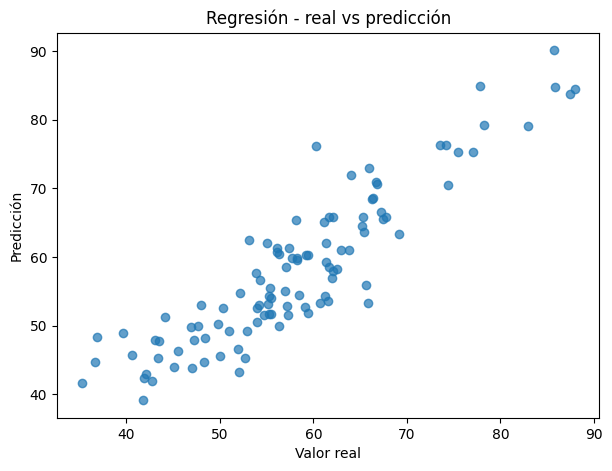

In [ ]:
modelo_C = crear_pipeline_mlp_regresor(hidden_layer_sizes=(32, 16), alpha=0.001)
pred_C, metricas_C = evaluar_regresion(modelo_C, X_train_C, X_test_C, y_train_C, y_test_C)


### Interpretación guiada
- Un **MAE** bajo significa que, en promedio, el error absoluto es pequeño.
- Un **RMSE** mucho mayor que el MAE sugiere la presencia de errores grandes en algunos casos.
- Un **R²** más alto suele indicar mejor ajuste, pero siempre debe interpretarse junto con MAE y RMSE.


---
## Sección D - Espiral multiclase o caso altamente no lineal
**Meta:** observar por qué una red neuronal puede ser útil cuando la frontera entre clases es compleja.

Esta sección es importante porque muestra una situación donde un modelo lineal tendría dificultades.  
La red neuronal puede aprender combinaciones no lineales de las entradas.


In [ ]:
df_D, X_D, y_D = cargar_seccion('D', 'clase')
resumen_eda(df_D, 'clase')

X_train_D, X_test_D, y_train_D, y_test_D = train_test_split(
    X_D, y_D, test_size=0.25, random_state=SEED, stratify=y_D
)


Sección D
  Filas y columnas: (450, 3)
  Variable objetivo: clase


,x1,x2,clase
0,0.0466,0.1945,0
1,0.0149,0.2169,0
2,0.1355,0.1919,0
3,0.0876,0.2367,0
4,0.0327,0.2678,0


Tipos de datos:


,tipo
x1,float64
x2,float64
clase,int64


Valores faltantes por columna:


,faltantes
x1,0
x2,0
clase,0


Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
x1,450.0,-0.021994,1.193653,-2.5019,-0.806800,0.06585,0.746875,2.7909
x2,450.0,-0.085416,1.180924,-2.7376,-0.934375,-0.07465,0.667300,2.6061
clase,450.0,1.000000,0.817405,0.0000,0.000000,1.00000,2.000000,2.0000


Distribución de la variable objetivo:


,conteo
clase,
0,150
1,150
2,150


In [ ]:
arquitecturas_D = [(12,), (24, 12), (32, 16), (48, 24)]
comparacion_D = comparar_arquitecturas_clasificacion(
    X_train_D, X_test_D, y_train_D, y_test_D,
    arquitecturas_D, alpha=0.0005, promedio='macro'
)
display(comparacion_D)


,arquitectura,accuracy,precision,recall,f1
0,"(24, 12)",0.6637,0.6844,0.6643,0.6684
1,"(48, 24)",0.6018,0.6431,0.5991,0.5775
2,"(32, 16)",0.5664,0.6934,0.5635,0.5397
3,"(12,)",0.5310,0.6099,0.5287,0.4886


Resultados del modelo
   accuracy: 0.6637
  precision: 0.6844
     recall: 0.6643
         f1: 0.6684
Reporte de clasificación
              precision    recall  f1-score   support

           0       0.83      0.63      0.72        38
           1       0.53      0.63      0.58        38
           2       0.69      0.73      0.71        37

    accuracy                           0.66       113
   macro avg       0.68      0.66      0.67       113
weighted avg       0.68      0.66      0.67       113



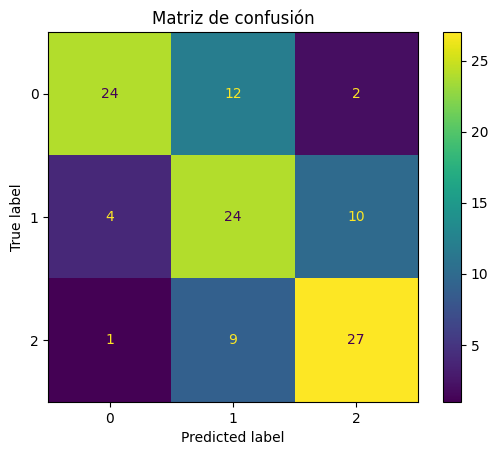

In [ ]:
modelo_D = crear_pipeline_mlp_clasificador(hidden_layer_sizes=(24, 12), alpha=0.0005)
pred_D, metricas_D = evaluar_clasificacion(modelo_D, X_train_D, X_test_D, y_train_D, y_test_D, promedio='macro')


### Reflexión de la Sección D
Cuando las fronteras son complejas, una red neuronal puede capturar patrones que serían difíciles para modelos lineales.  
Sin embargo, esto no significa que “más grande siempre sea mejor”. El rendimiento depende también de la calidad de los datos, la escala y la regularización.


---
## Exportación de predicciones
Guardaremos una salida de la sección C para que puedas revisar el desempeño de la regresión y entregar evidencia del laboratorio.


In [ ]:
modelo_final_lab4 = modelo_C
modelo_final_lab4.fit(X_train_C, y_train_C)

exportar = X_test_C.copy().reset_index(drop=True)
exportar['real'] = y_test_C.reset_index(drop=True)
exportar['prediccion'] = modelo_final_lab4.predict(X_test_C)

salida = BASE_DIR / 'predicciones_lab4_v2.csv'
exportar.to_csv(salida, index=False)
print(f'Archivo generado: {salida.resolve()}')
display(exportar.head(10))


Archivo generado: /content/predicciones_lab4_v2.csv


,temperatura_exterior_c,humedad_exterior_pct,ocupacion_personas,area_m2,equipos_activos,hora_pico,real,prediccion
0,21.83,39.91,70,97.0,11,1,43.37,45.327347
1,17.00,87.70,84,242.2,26,0,65.95,72.908462
2,23.84,62.80,98,291.3,10,0,57.28,51.526404
3,24.23,44.88,37,175.6,10,1,45.12,44.054213
4,21.84,73.28,54,141.2,7,1,41.91,42.372361
5,16.89,60.56,21,139.1,22,0,55.48,54.007240
6,25.14,60.99,107,125.2,28,0,57.43,61.358136
7,3.96,82.15,24,178.6,23,1,77.85,84.913563
8,23.73,60.83,17,358.6,14,1,66.27,68.506508
9,34.61,33.07,118,267.7,17,1,66.77,70.704976


## Errores frecuentes al usar MLP
1. Entrenar sin escalar las variables.
2. Elegir una arquitectura grande desde el inicio sin comparación previa.
3. Interpretar una sola métrica como suficiente.
4. No distinguir entre métricas de clasificación y de regresión.
5. Concluir demasiado a partir de una sola corrida del modelo.


## Cierre del laboratorio
Después de completar este notebook, deberías poder responder:
1. ¿Qué representa `hidden_layer_sizes`?
2. ¿Por qué una red neuronal necesita variables escaladas?
3. ¿Qué diferencia hay entre evaluar clasificación y regresión?
4. ¿Cómo afecta `alpha` al entrenamiento?
5. ¿Qué aprendiste al comparar arquitecturas?

### Entregables sugeridos
- tabla con las arquitecturas comparadas;
- archivo `predicciones_lab4_v2.csv`;
- breve reflexión sobre la mejor configuración encontrada.

### Bibliografía de apoyo
- `scikit-learn User Guide` – sección redes neuronales.  
- Goodfellow, Bengio, Courville – *Deep Learning*.  
- Géron – *Hands-On Machine Learning*.


Respuestas — Cierre del laboratorio
1. ¿Qué representa hidden_layer_sizes?

Indica el número de capas ocultas en la red neuronal y la cantidad de neuronas que contiene cada una de esas capas. Por ejemplo, (64, 32) significa dos capas ocultas con 64 y 32 neuronas, respectivamente.

2. ¿Por qué una red neuronal necesita variables escaladas?

Es fundamental escalar las variables para que todas contribuyan de manera equitativa al modelo. Si una variable tiene un rango de valores mucho mayor que otra (ej. 0-1000 vs. 0-1), podría dominar el proceso de entrenamiento y sesgar los resultados. Escalar asegura que todas las características estén en una magnitud similar, permitiendo que la red aprenda de todas ellas de forma balanceada.

3. ¿Qué diferencia hay entre evaluar clasificación y regresión?

La evaluación de modelos de clasificación se centra en cuán bien el modelo asigna las entradas a categorías discretas (ej. si acertó la clase), usando métricas como accuracy o f1-score. En cambio, la evaluación de regresión mide la proximidad de las predicciones del modelo a valores numéricos continuos reales, utilizando métricas como MAE, RMSE o R².

4. ¿Cómo afecta alpha al entrenamiento?

El parámetro alpha controla la regularización L2. Actúa como un 'freno' o penalización sobre los pesos de la red, lo que ayuda a prevenir el sobreajuste. Un alpha más alto limita más la complejidad del modelo, reduciendo el riesgo de memorizar el ruido en los datos de entrenamiento. Un alpha demasiado bajo podría llevar al sobreajuste, mientras que uno muy alto podría resultar en un modelo demasiado simplificado.

5. ¿Qué aprendiste al comparar arquitecturas?

La principal lección es que una arquitectura más grande no siempre se traduce en un mejor rendimiento. La elección óptima de la arquitectura de la red neuronal es muy dependiente del problema específico y del conjunto de datos. Para datos simples, una red más pequeña suele ser suficiente, mientras que problemas más complejos pueden requerir redes más grandes, pero siempre manteniendo un equilibrio para evitar el sobreajuste (como se observó en la Sección C, donde la arquitectura más grande no fue la mejor).